In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import pandas as pd
import numpy as np
import shutil
import os

C:\Users\setea\anaconda3\envs\PracticasAplicacionesIA\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
C:\Users\setea\anaconda3\envs\PracticasAplicacionesIA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Obtener la ruta donde kagglehub guarda los datos
path = kagglehub.dataset_download("henrysue/online-shoppers-intention")

print(f"La carpeta está en: {path}")

# Eliminar la carpeta completa para resetear el archivo dañado
try:
    shutil.rmtree(path)
    print("Carpeta eliminada con éxito. Ya se puede volver a descargar el dataset.")
except Exception as e:
    print(f"No se pudo eliminar: {e}")

La carpeta está en: C:\Users\setea\.cache\kagglehub\datasets\henrysue\online-shoppers-intention\versions\1
✅ Carpeta eliminada con éxito. Ya puedes volver a descargar el dataset.


In [3]:
path = kagglehub.dataset_download("henrysue/online-shoppers-intention")
file_path = os.path.join(path, "online_shoppers_intention.csv")

# 2. Leer con configuración "todoterreno"
df = pd.read_csv(
    file_path, 
    sep=None,             # Detecta automáticamente si es coma o punto y coma
    engine='python',      # El motor de Python es más flexible con errores de formato
    encoding='latin1',    # Evita el error de Unicode original
    on_bad_lines='skip'   # Si una línea está rota, la salta en lugar de detenerse
)

# 3. Verificar
print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")
print(df.head())

100%|██████████| 252k/252k [00:00<00:00, 1.51MB/s]

Extracting files...


Dataset cargado con 12330 filas y 18 columnas.
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0

In [14]:
print("Valores nulos por columna:")
print(df.isnull().sum())

# 3. Eliminar duplicados
duplicados = df.duplicated().sum()
print(f"\nFilas duplicadas encontradas: {duplicados}")
df = df.drop_duplicates()

# 4. Ver los tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

Valores nulos por columna:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Filas duplicadas encontradas: 125

Tipos de datos:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
O

In [15]:
print("Información del dataset:")
print(df.info())

print("Descripción de los datos:")
df.describe()

Información del dataset:
<class 'pandas.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType  

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


C:\Users\setea\AppData\Local\Temp\ipykernel_7848\3661534798.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Revenue', data=df, palette='viridis')
C:\Users\setea\AppData\Local\Temp\ipykernel_7848\3661534798.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='VisitorType', data=df, palette='magma')


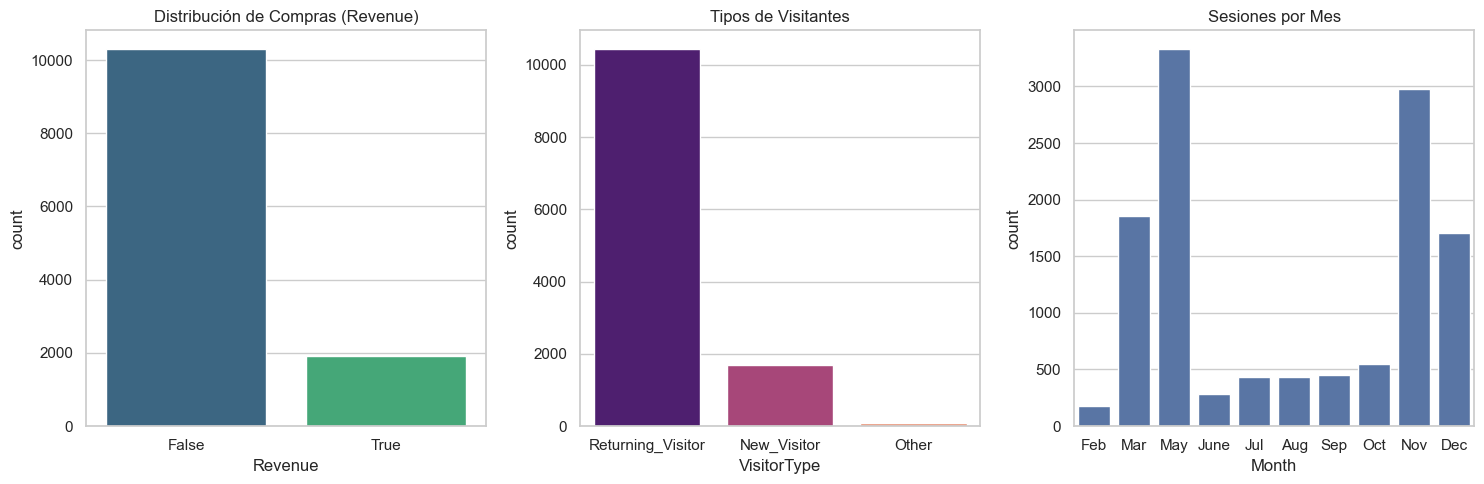

In [16]:
# Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Graficar la variable objetivo: ¿Cuántos compran (Revenue)?
plt.subplot(1, 3, 1)
sns.countplot(x='Revenue', data=df, palette='viridis')
plt.title('Distribución de Compras (Revenue)')

# Graficar tipos de visitantes
plt.subplot(1, 3, 2)
sns.countplot(x='VisitorType', data=df, palette='magma')
plt.title('Tipos de Visitantes')

# Graficar tráfico por mes
plt.subplot(1, 3, 3)
sns.countplot(x='Month', data=df, order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Sesiones por Mes')

plt.tight_layout()
plt.show()

In [17]:
print(df['Revenue'].value_counts())
print(df['VisitorType'].value_counts())
print(df['Month'].value_counts())

Revenue
False    10297
True      1908
Name: count, dtype: int64
VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64
Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64


### 1. Revenue: 
- Hay un desequilibrio evidente, la mayoría de las sesiones terminan en no comprar el producto, 84.5% (10.422), mientras que las compras solo son 15.5% (1.908).
- Hay que hacer algo para ajustarlo.

### 2. Tipos de visitantes:
- Los visitantes que regresan (10.551) superan por mucho a los nuevos (1.694) y a los demás (85).
- La tienda depende fuertemente de la retención. Pero hay que tener un detalle en mente, que es que los que nuevos suelen tener una tasa de compra más alta por sesión (compra impulsiva).
- Como hay pocos de 'Other' podríamos ignorarlo.

### 3. Meses
- Mayo y Noviembre tienen mayor volumen de sesiones.
- Febrero tiene poco volumen, raro al tener San Valentín, es posible que haya mal marketing.

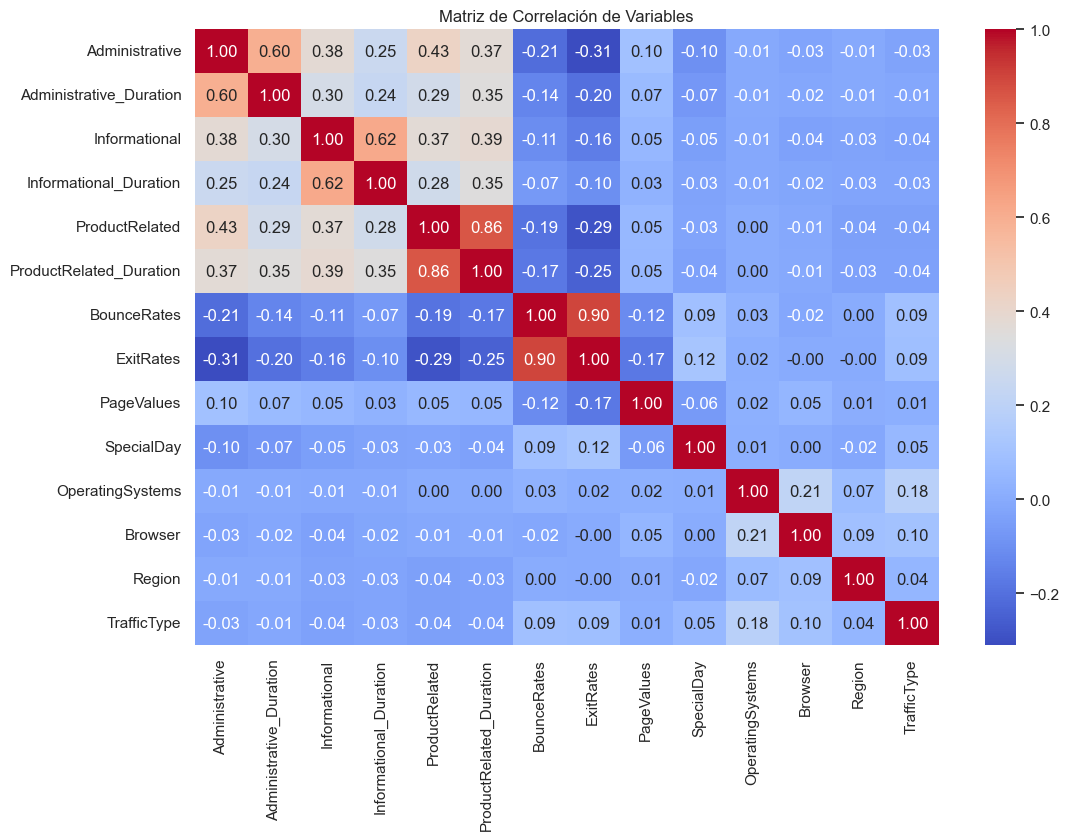

In [18]:
# 1. Correlación entre variables numéricas
plt.figure(figsize=(12, 8))
# Solo columnas numéricas para la correlación
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación de Variables')
plt.show()

### Correlaciones:
- Alta correlación 90%, entre 'BoundRates' y 'ExitRates', esto es normal ya que si un cliente sata, sale del sitio.
- Alta correlación 86%, entre 'ProductRelated' y 'ProductRelated_Duration', es decir, entre la cantidad de productos visitados y el tiempo que pasan en estos.
- La administración y su tiempo en esta también tienen alta correlación 60%.
- También tienen alta correlación las páginas informativas y su duración 62%.

C:\Users\setea\AppData\Local\Temp\ipykernel_7848\2774806390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Weekend', data=df, palette='inferno')


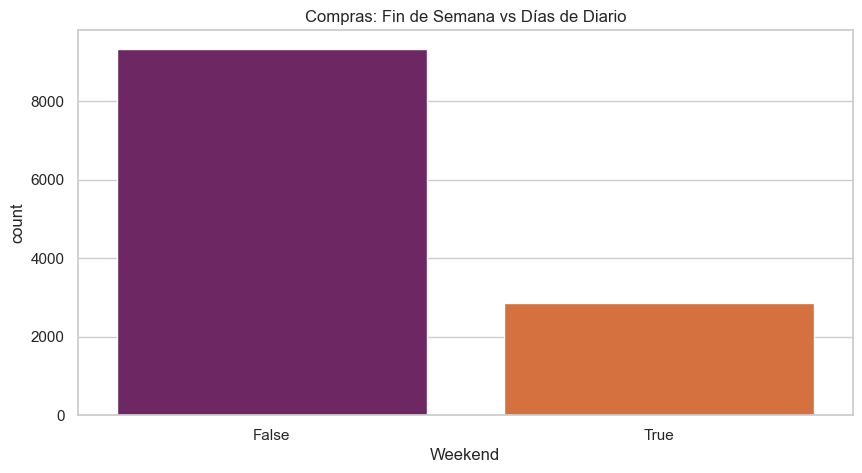

In [19]:
# Relación entre Fin de Semana y Compra
plt.figure(figsize=(10, 5))
sns.countplot(x='Weekend', data=df, palette='inferno')
plt.title('Compras: Fin de Semana vs Días de Diario')
plt.show()

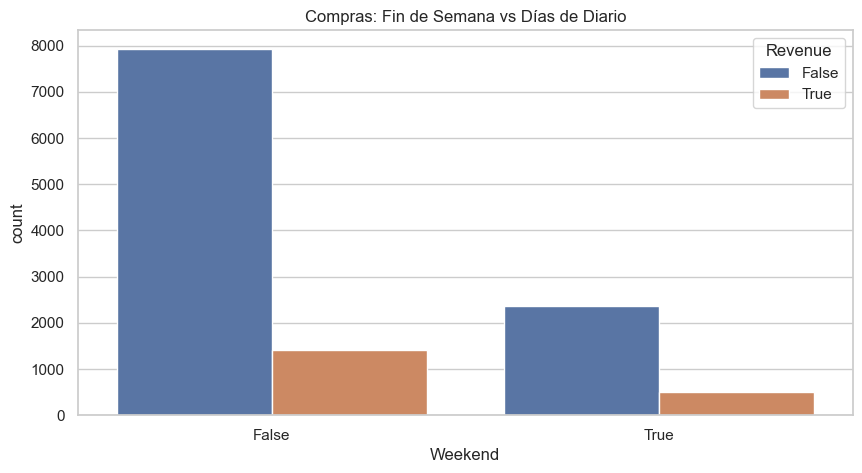

In [20]:
# Relación entre Fin de Semana y Compra
plt.figure(figsize=(10, 5))
sns.countplot(x='Weekend', hue='Revenue', data=df)
plt.title('Compras: Fin de Semana vs Días de Diario')
plt.show()

### Compras por finde semana y Diario.

- El volumen está en la semana: La gran mayoría de las sesiones ocurren entre lunes y viernes (Weekend: False). Esto sugiere que los usuarios navegan mientras trabajan o en sus rutinas diarias.

- No parece haber un "efecto fin de semana" que dispare la intención de compra; el comportamiento es bastante constante a lo largo de la semana.

In [4]:
# Crea una tabla comparativa de Mes vs Revenue
resumen_ventas = pd.crosstab(df['Month'], df['Revenue'])

# Ordenar los meses cronológicamente (opcional pero recomendado)
meses_ordenados = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
resumen_ventas = resumen_ventas.reindex(meses_ordenados)

print(resumen_ventas)

Revenue  False  True 
Month                
Feb        181      3
Mar       1715    192
May       2999    365
June       259     29
Jul        366     66
Aug        357     76
Sep        362     86
Oct        434    115
Nov       2238    760
Dec       1511    216


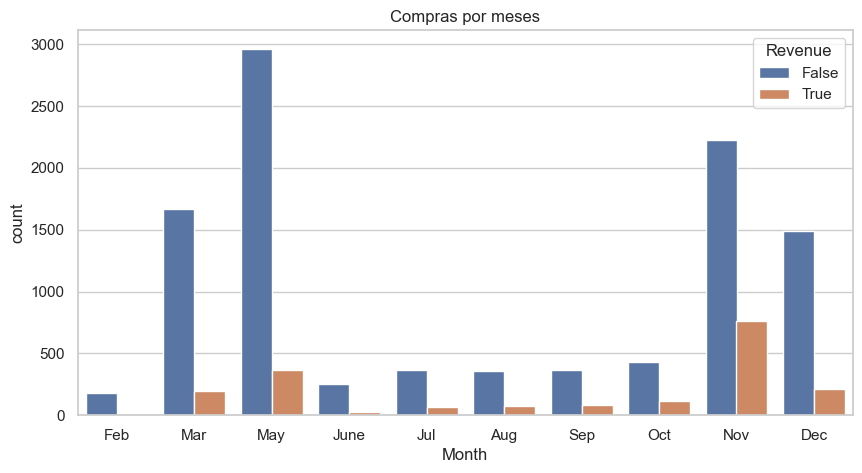

In [21]:
# Relación entre Fin de Semana y Compra
plt.figure(figsize=(10, 5))
sns.countplot(x='Month', hue='Revenue', data=df, order=['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.title('Compras por meses')
plt.show()

### Compras por meses
- Mayo tiene más sesiones totales, pero Noviembre es el mes con más compras en terminos absolutos. (Black Friday?).
- Mayo es tráfico de compras exploratorio.
- Febrero y Junio muestran compras casi nulas. Parece que las campañas de marketing no están surgiendo efecto.

In [22]:
print(df['OperatingSystems'].value_counts())

OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64


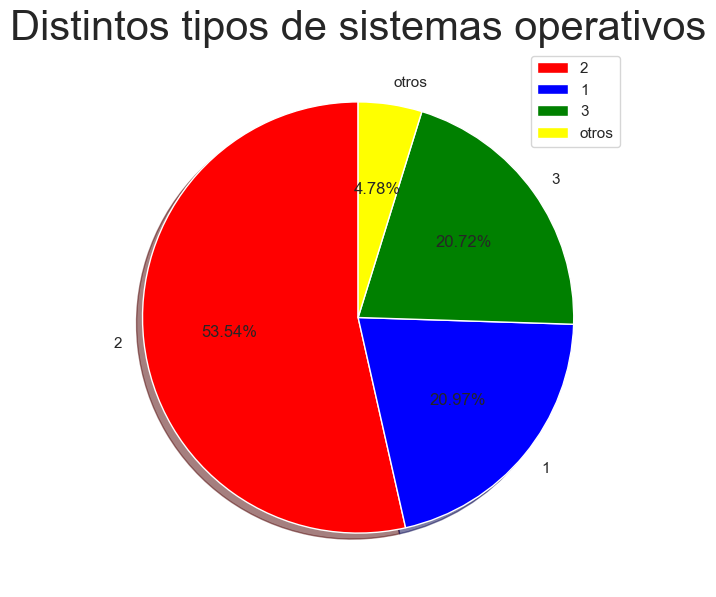

In [23]:
plt.rcParams['figure.figsize'] = (18, 7)
size = [6601, 2585, 2555, 589]
colors = ['red', 'blue', 'green', 'yellow']
labels = "2", "1", "3", "otros"

plt.subplot(1, 2, 2)
plt.pie(size, colors = colors, labels = labels, shadow = True, autopct = '%.2f%%', startangle=90)
plt.title('Distintos tipos de sistemas operativos', fontsize = 30)
plt.axis('off')
plt.legend()
plt.show()

### Sistemas operativos
- El sistema operativo 2 domina con un 53.54% --> Posiblemente windows.
- 1 y 3 son casi idénticos, con un 20.97% y 20.72% respectivamente. --> Puede ser Moviles (android, IOS), o el uso de macOS.

In [24]:
print(df['Browser'].value_counts())

Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64


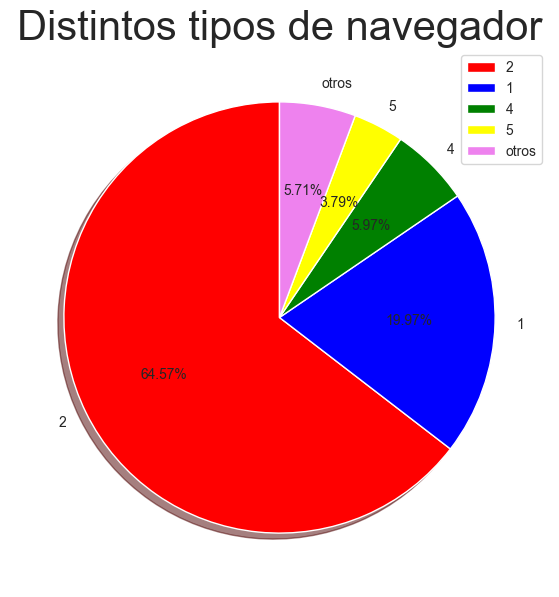

In [7]:
plt.rcParams['figure.figsize'] = (18, 7)
size = [7961, 2462, 736, 467, 704]
colors = ['red', 'blue', 'green', 'yellow', 'violet']
labels = "2", "1", "4", "5", "otros"

plt.subplot(1, 2, 2)
plt.pie(size, colors = colors, labels = labels, shadow = True, autopct = '%.2f%%', startangle=90)
plt.title('Distintos tipos de navegador', fontsize = 30)
plt.axis('off')
plt.legend()
plt.show()

### Navegadores
- Domina claramente el navegador 2 con un 64.57%, casi dos tercios de los usuarios utilizan el mismo navegador. --> Seguramente Google Chrome.
- El navegador 1 es el siguiente con un 19.97% --> podría ser safari, reflejando los usuarios de apple.
- Los demás suman menos del 15% del total.
- Está bien para saber cual navegador hay que priorizar para que la página funcione de manera óptima.

In [26]:
print(df['Region'].value_counts())

Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64


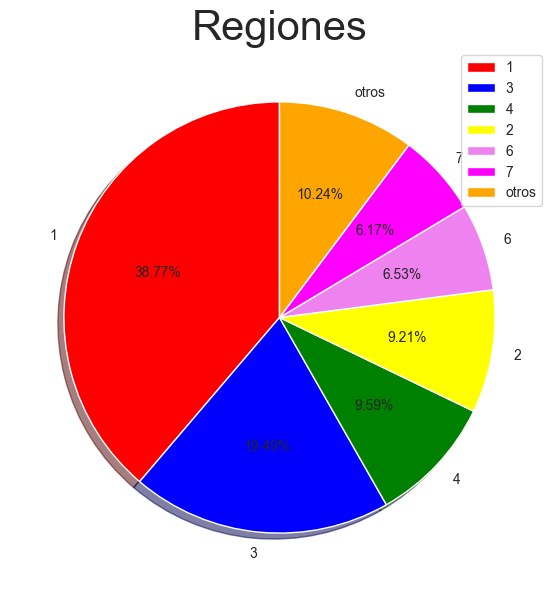

In [6]:
plt.rcParams['figure.figsize'] = (18, 7)
size = [4780, 2403, 1182, 1136, 805, 761, 511+434+318]
colors = ['red', 'blue', 'green', 'yellow', 'violet', "magenta", "orange"]
labels = "1", "3", "4", "2", "6", "7", "otros"

plt.subplot(1, 2, 2)
plt.pie(size, colors = colors, labels = labels, shadow = True, autopct = '%.2f%%', startangle=90)
plt.title('Regiones', fontsize = 30)
plt.axis('off')
plt.legend()
plt.show()

### Regiones
- El 1 es el mercado principal con un 38.77%, Casi 4 de cada 10 personas provienen de esta región.
- La siguiente es el 3 con un 19.49%.
- Las demás regiones están bastante equilibradas alrededor de 10% a 7%.
- Se puede reforzar en las regiones con más usuarios o intentar una expansión a las regiones con menos usuarios.

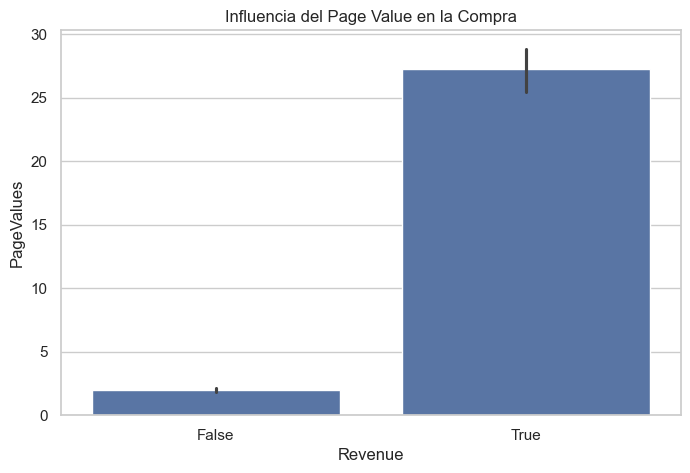

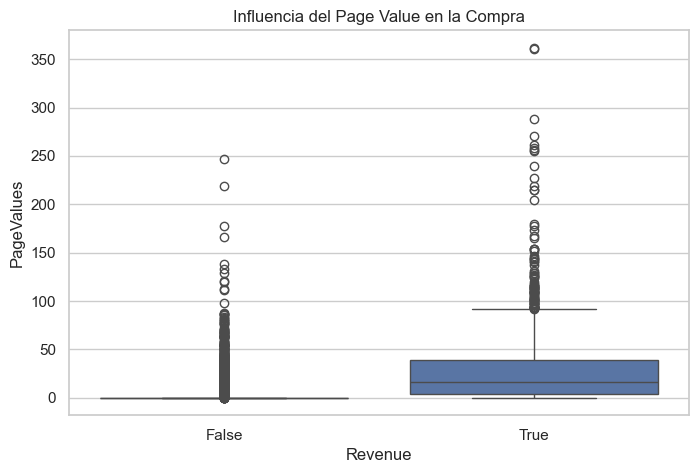

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Revenue', y='PageValues', data=df)
plt.title('Influencia del Page Value en la Compra')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('Influencia del Page Value en la Compra')
plt.show()

### Influencia del page value
- Los usuarios que no compran tienen un pageValue cercano al 0. En cambio los que compran disparan esta métrica por encima del 25 de media.
- Confirma que el pageValue es el mejor predictor de éxito.
- Se ve también que hay varios outliers hasta los 350. Estos son compras de productos de lujo o carritos llenos.

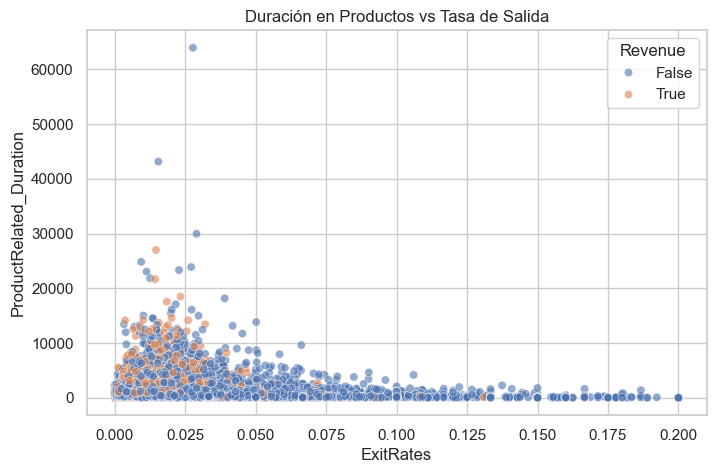

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='ExitRates', y='ProductRelated_Duration', hue='Revenue', data=df, alpha=0.6)
plt.title('Duración en Productos vs Tasa de Salida')
plt.show()

### Duración en productos vs tasa de salida
- La mayoría de las compras se concentran en el cuadrante de baja Tasa de Salida y alta duración
- A medida que el exit rate sube las probabilidades de compra desaparecen casi por completo.
- No basta con que el usuario pase mucho tiempo en el producto, sino que lka tasa de salida de esa página también influye.

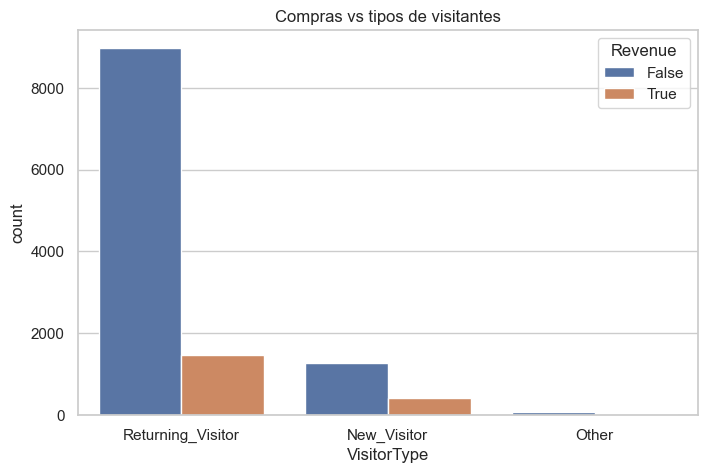

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x='VisitorType', hue='Revenue', data=df)
plt.title('Compras vs tipos de visitantes')
plt.show()

### Compras vs tipo de visitantes
- Los usuarios que vuelven generan el mayor volumen de ventas, pero también el mayor columen de abandonos.
- Aunque los nuevos visitantes son menos tienen una tasa de conversión más equilibrada, es decir, un usuario nuevo que entra tiene más posibilidades de comprar.

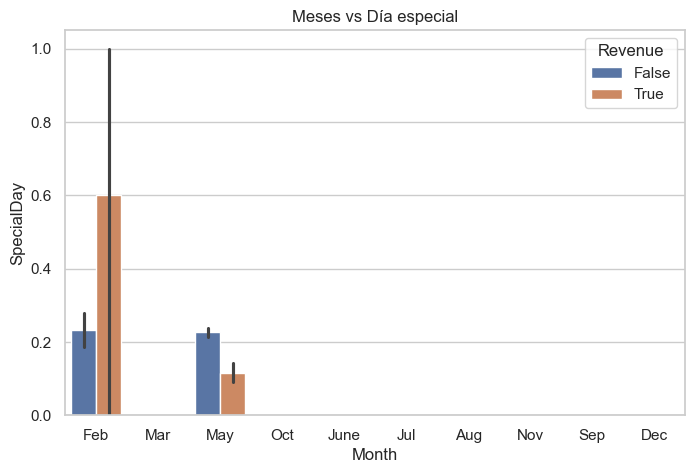

In [31]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Month', y='SpecialDay', hue='Revenue', data=df)
plt.title('Meses vs Día especial')
plt.show()

### Meses vs Dia especial
- Único mes conde la métrica de dia especial es alta por compras exitosas --> San valentin
- Mayo también pero los resultados son inferiores.
- Los demás meses no dependen de una fecha única, sino de una temporada de compras continua (black friday, Navidad).


- Febrero es el mes con más influencia de Día Especial (San Valentín), pero los números muestran que es un fracaso comercial en volumen: solo 3 compras frente a 181 abandonos (apenas un 1.6% de éxito).

C:\Users\setea\AppData\Local\Temp\ipykernel_7848\4263568626.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Revenue', y='BounceRates', data=df, palette='magma')


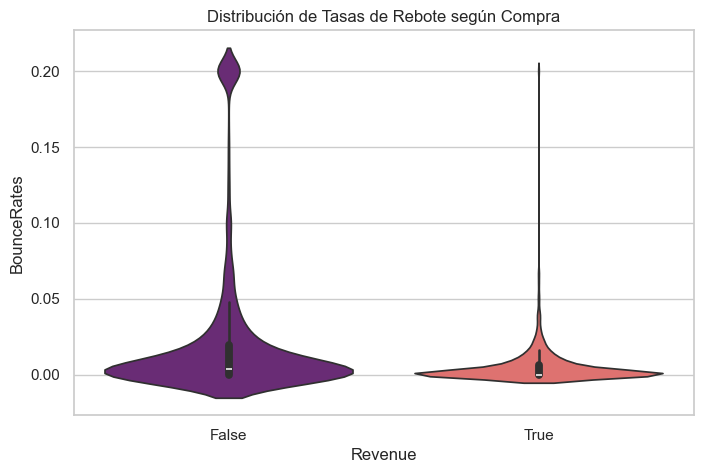

In [32]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Revenue', y='BounceRates', data=df, palette='magma')
plt.title('Distribución de Tasas de Rebote según Compra')
plt.show()

### Distribución tasas de rebote según compra
- Los usuarios que no compran tienen una base muy ancha en el 0, pero muestra una llama que sube hasta 0.20. Esto significa que hay un grupo considerable de personas que entran y salen inmediatamente de la página (rebote).
- La distribución de los que si compran es casi plana pegada al 0.
- Si el usuario no encuentra lo que busca en los primeros segundos, no hay posibilidad de conversión. Mantener el bounceRate cerca del 0 es requisito mínimo para que haya compras.

In [33]:
orden_freq = df['TrafficType'].value_counts()
print(orden_freq)

TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7       40
15      37
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64


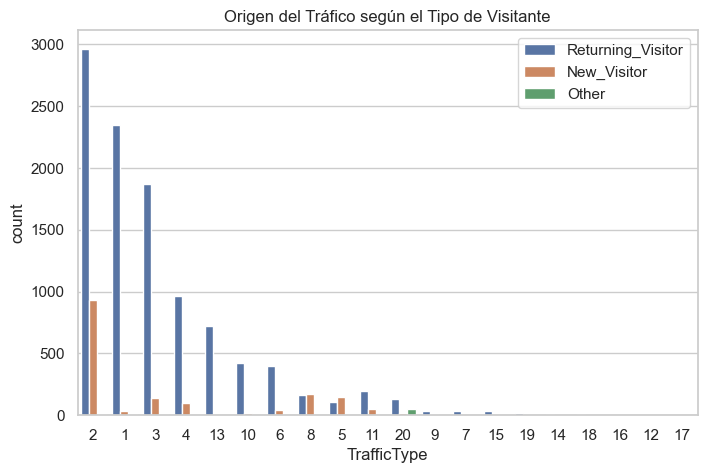

In [34]:
plt.figure(figsize=(8, 5))
sns.countplot(x='TrafficType', hue='VisitorType', data=df, order=orden_freq.index)
plt.title('Origen del Tráfico según el Tipo de Visitante')
plt.legend(loc='upper right')
plt.show()

### Origen del trafico según tipo de visitantes
- Los tipos de tráfico 2, 1 y 3 son los principales. La mayor cantidad de nuevos visitantes se encuentran el tráfico 2, lo que sugiere que es un canal de captación.
- El 1 son casi todos antiguos, lo que indica fidelización.

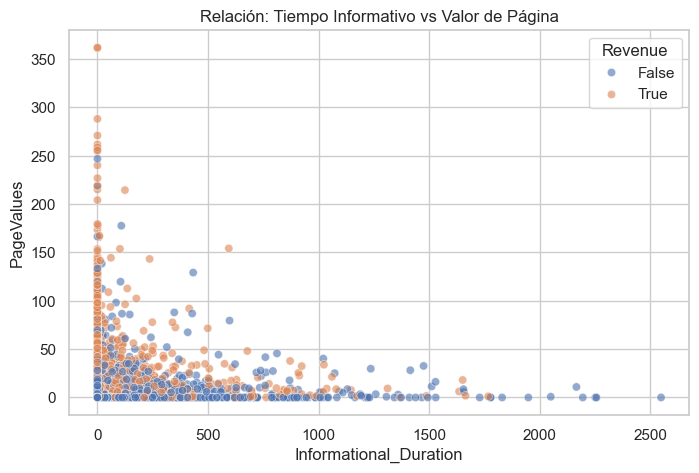

In [35]:
plt.figure(figsize=(8, 5))
# Usamos un scatter plot para ver la relación entre tiempo informativo y valor de página
sns.scatterplot(x='Informational_Duration', y='PageValues', hue='Revenue', data=df, alpha=0.6)
plt.title('Relación: Tiempo Informativo vs Valor de Página')
plt.show()

### Tiempo informativo y valor de compra
- La mayoría de las compras están acumuladas en donde hay mucho page value y poca duración de información.
- A medida que el usuario pasa de los 500 segundos en páginas informativas las compras empiezan a escasear.
- Los usuarios que compran no necesitan leer cosas como el quienes somos durante mucho tiempo, si pasa mucho tiempo es posible que este perdido o indeciso.